In [10]:
import numpy as np
from scipy.spatial import KDTree

N = int(1e7)
points = np.random.rand(N, 3) * 100

In [11]:
tree = KDTree(points)

In [95]:
import time
import timeit

In [137]:
target = [50., 50., 50.]

rad = 30.
def query():
    return tree.query_ball_point(target, rad)

ntrials = 100
total_time = timeit.timeit(query, number=ntrials)

print(f"KDTree query time: {total_time / ntrials:.6e} seconds per query")


KDTree query time: 3.570573e-02 seconds per query


In [139]:
target = [50., 50., 50.]
k = 1000000
def query():
    return tree.query(target, k=k)

ntrials = 2
total_time = timeit.timeit(query, number=ntrials)

print(f"KDTree query time: {total_time / ntrials:.6e} seconds per query")

KDTree query time: 2.511471e-01 seconds per query


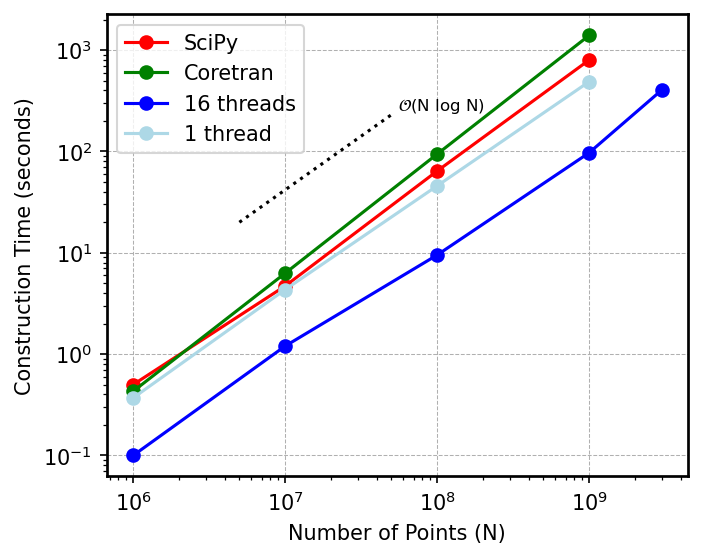

In [135]:
#Comparison Plot: CONSTRUCTION TIME

import matplotlib.pyplot as plt

# Data points (Number of points N and Construction time in seconds)
N_gcc_parallel = np.array([1e6,1e7,1e8,1e9,3e9])
N_gcc_serial = np.array([1e6,1e7,1e8,1e9])
time_scipy_serial = np.array([0.5, 4.7, 64, 797])
time_gcc_serial = np.array([0.37, 4.33, 45.7, 487., ])  
time_gcc_parallel = np.array([0.1, 1.2, 9.5, 96.9, 402.])  
time_coretran_serial = np.array([0.43, 6.28, 94, 1393])

# Reference O(N log N) scaling
N_ref = np.array([5e6,5e7])
t0 = 20.
N0 = 5e6
scaling_ref = (t0 / (N0 * np.log(N0))) * N_ref * np.log(N_ref)

# Plot settings
plt.figure(figsize=(5,4), dpi = 150)
plt.loglog(N_gcc_serial, time_scipy_serial, 'o-', label='SciPy', color='red')
plt.loglog(N_gcc_serial, time_coretran_serial, 'o-', label='Coretran', color='green')
plt.loglog(N_gcc_parallel, time_gcc_parallel, 'o-', label='16 threads', color='blue')
plt.loglog(N_gcc_serial, time_gcc_serial, 'o-', label='1 thread', color='lightblue')
plt.loglog(N_ref, scaling_ref, color='black', linestyle='dotted')
plt.text(1.1*N_ref[-1], 1.1*scaling_ref[-1], '$\mathcal{O}$(N log N)', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Points (N)')
plt.ylabel('Construction Time (seconds)')
plt.legend()
#thicker axis lines
plt.gca().spines['top'].set_linewidth(1.3)
plt.gca().spines['right'].set_linewidth(1.3)
plt.gca().spines['bottom'].set_linewidth(1.3)
plt.gca().spines['left'].set_linewidth(1.3)

plt.grid(True, which="major", linestyle='--', linewidth=0.5)
plt.savefig('construction.png')

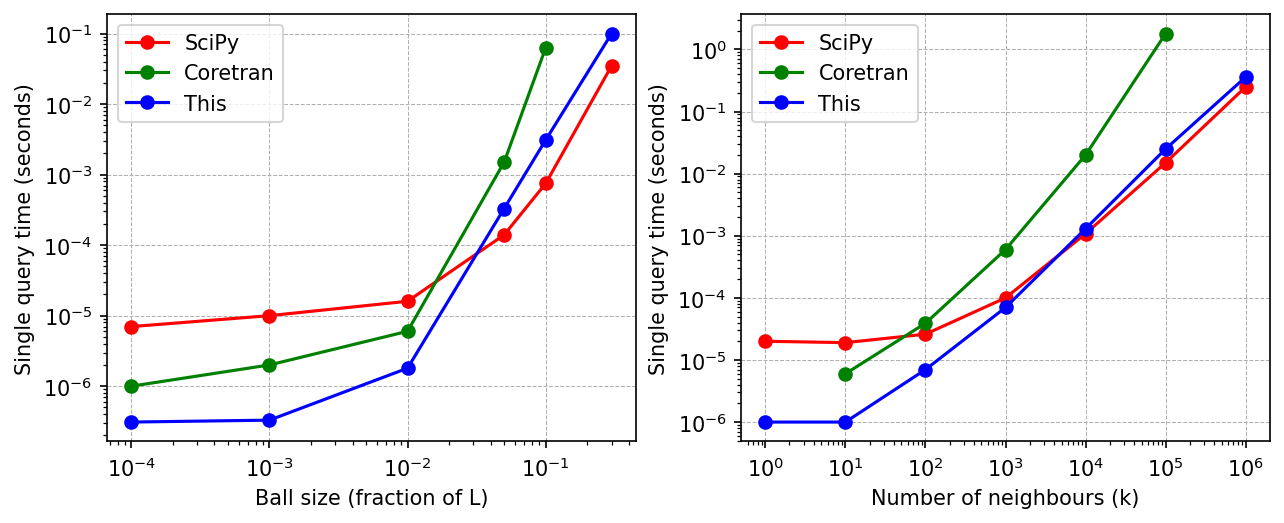

In [149]:
# Plot QUERY TIME
# Not plot here but query time is as fast as Coretran's implementation
k = [1,10,100,1000,10000,100000, 1e6]
ball = [0.01,0.1,1,5,10,30]
t_k_gcc = [1e-6,1e-6,7e-6,7.e-5, 1.3e-3, 2.5e-2, 0.36]
t_k_scipy = [2.e-5, 1.9e-5, 2.6e-5, 1.e-4, 1.08e-3, 1.5e-2, 0.25]
t_k_coretran = [np.nan, 6e-6, 3.9e-5, 6e-4, 2e-2, 1.8, np.nan]
t_ball_gcc = [3.1e-7, 3.3e-7, 1.8e-6, 3.3e-4, 3.1e-3, 0.1]
t_ball_scipy = [7e-6, 1e-5, 1.6e-5, 1.4e-4, 7.5e-4, 3.5e-2]
t_ball_coretran = [1e-6, 2e-6, 6e-6, 1.5e-3, 6.3e-2]

# Plot settings ( vertical)
plt.figure(figsize=(10,3.7), dpi = 150,)
plt.subplot(1,2,1)
plt.loglog(np.array(ball[:len(t_ball_scipy)])/100., t_ball_scipy, 'o-', label='SciPy', color='red')
plt.loglog(np.array(ball[:len(t_ball_coretran)])/100., t_ball_coretran, 'o-', label='Coretran', color='green')
plt.loglog(np.array(ball)/100., t_ball_gcc, 'o-', label='This', color='blue')
plt.xlabel('Ball size (fraction of L)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)

plt.subplot(1,2,2)
plt.loglog(k[:len(t_k_scipy)], t_k_scipy, 'o-', label='SciPy', color='red')
plt.loglog(k[:len(t_k_coretran)], t_k_coretran, 'o-', label='Coretran', color='green')
plt.loglog(k, t_k_gcc, 'o-', label='This', color='blue')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)


plt.savefig('query.png')
